<a href="https://colab.research.google.com/github/ghfreiree/bank-customer-churn-prediction/blob/main/bank_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo: Criar um modelo para prever o churn dos clientes do banco

# Sobre o dataset

Abaixo está o mapeamento e a descrição de cada um dos atributos presentes no conjunto de dados:

- `RowNumber` (Numérico): Corresponde ao número do registro (linha) e não possui efeito no modelo.

- `CustomerId` (Numérico): Identificador único do cliente; contém valores aleatórios e não influencia o churn.

- `Surname` (Texto): Sobrenome do cliente; não possui impacto na decisão de deixar o banco.

- `CreditScore` (Numérico): Pontuação de crédito do cliente. Clientes com scores mais altos tendem a ser menos propensos a deixar o banco.

- `Geography` (Categórico): Localização geográfica do cliente; pode influenciar a taxa de retenção.

- `Gender` (Categórico): Gênero do cliente; útil para explorar se há disparidade de comportamento no churn.

- `Age` (Numérico): Idade do cliente. É um fator relevante, pois a demografia frequentemente dita o comportamento de fidelidade.

- `Tenure` (Numérico): Número de anos que o cliente está com o banco. Normalmente, clientes mais antigos são mais leais.

- `Balance` (Numérico): Saldo bancário do cliente. Um bom indicador, visto que saldos maiores tendem a reter o cliente.

- `NumOfProducts` (Numérico): Quantidade de produtos que o cliente adquiriu ou utiliza no banco.

- `HasCrCard` (Binário): Indica se o cliente possui ou não cartão de crédito.

- `IsActiveMember` (Binário): Indica se o cliente é um membro ativo no banco. Membros ativos têm menor propensão ao churn.

- `EstimatedSalary` (Numérico): Salário estimado do cliente.

- `Complain` (Binário): Indica se o cliente fez uma reclamação. (Nota: Atributo removido do modelo devido a vazamento de dados / correlação perfeita com o alvo).

- `Satisfaction Score` (Numérico): Pontuação de satisfação dada pelo cliente em relação à resolução de sua reclamação.

- `Card Type` (Categórico): Tipo de cartão que o cliente possui (ex: Gold, Platinum, Diamond).

- `Point Earned` (Numérico): Pontos acumulados pelo cliente ao utilizar o cartão de crédito.

- `Exited` (Binário): Variável Alvo (Target). Indica se o cliente deixou o banco (1) ou continuou ativo (0).

# Conhecendo os dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.pipeline import Pipeline as imbpipeline

In [2]:
path = '/content/Customer-Churn-Records.csv'

df = pd.read_csv(path)
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df['CustomerId'].nunique() # Verificando se há 10k id's diferentes

10000

In [6]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Geography']) # Dropando colunas que não agregam a nossa análise
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


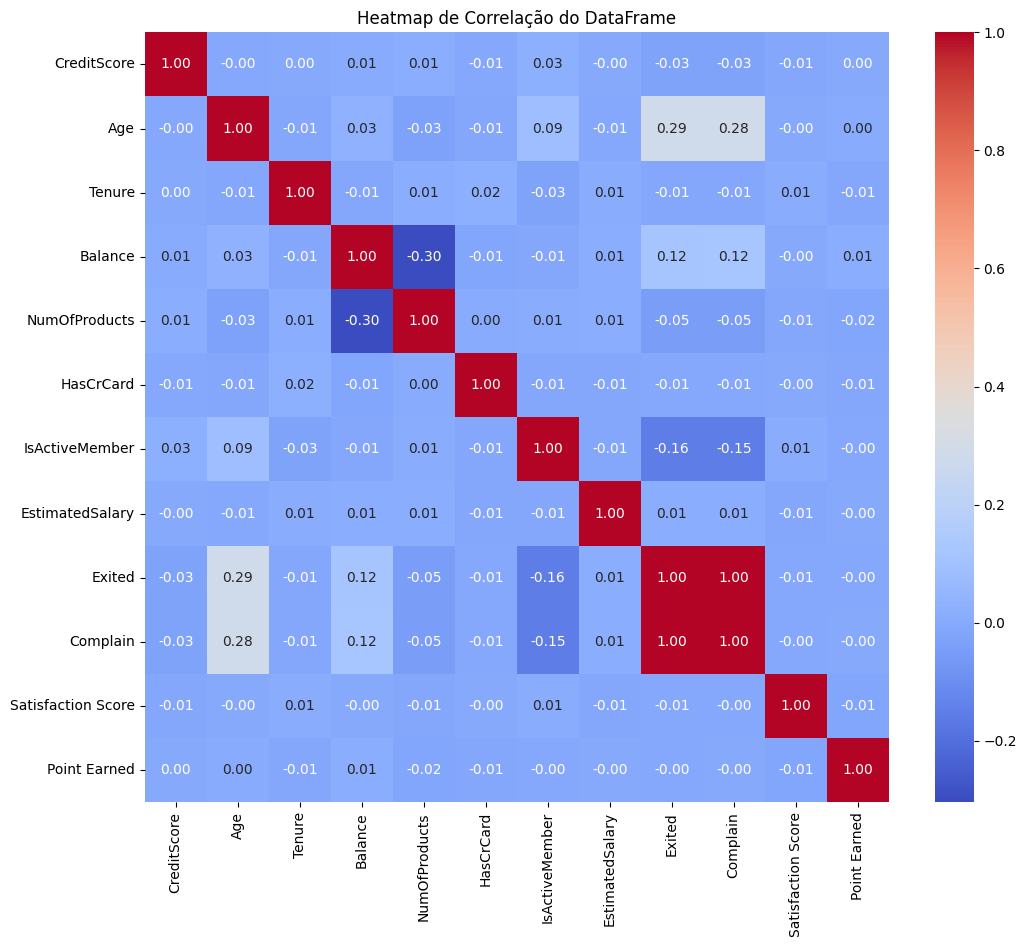

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap de Correlação do DataFrame')
plt.show()

In [8]:
df = df.drop(columns=['Complain'])

Dropamos a coluna `Complain` por apresentar 100% de correlação com o churn

# Modelo

## Preparação dos dados

In [9]:
x = df.drop(columns=['Exited'])
y = df['Exited']

In [10]:
cols_categoricas = ['Gender', 'Card Type']

In [11]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'), # Drop if_binary significa que as colunas com valores categóricos binários não serão alteradas
    cols_categoricas # Colunas que serão aplicadas o one hot encoder
),
    remainder = 'passthrough', # Faz com que as demais colunas permaneçam
    sparse_threshold=0) # Faz com que as colunas tranformadas matenham seus valores 0 ou 1

In [12]:
x = one_hot.fit_transform(x) # Realiza a transformação do onehot

In [13]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [14]:
y

array([1, 0, 1, ..., 1, 1, 0])

A separação dos dados será feita em 3 partes:
- Treino: dados para treinar o modelo
- Validação: dados para validar o desempenho do modelo
- Teste: dados para após as validações e otimizações do modelo, testar o desempenho com dados reais

In [15]:
x, x_teste, y, y_teste = train_test_split(x, y, test_size = 0.15, stratify = y, random_state = 6) # 15% dos dados serão para teste
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify = y, random_state = 5) # Separa os dados de treino dos dados de validação

## Validação

In [16]:
modelo = DecisionTreeClassifier()
modelo.fit(x_treino, y_treino)
print(f'Acurácia de treino: {modelo.score(x_treino, y_treino)}') # Acurácia 100% para os dados de treino
print(f'Acurácia de validação: {modelo.score(x_val, y_val)}')

Acurácia de treino: 1.0
Acurácia de validação: 0.7830588235294118


Aqui o modelo atingiu uma acurácia de 100% com os dados de treino, ou seja, ele não está aprendendo, mas sim decorando os dados. É necessário definir a profundidade da árvore de decisão.

In [17]:
modelo = DecisionTreeClassifier(max_depth = 10)
modelo.fit(x_treino, y_treino)
print(f'Acurácia de treino: {modelo.score(x_treino, y_treino)}') # Acurácia != 100%
print(f'Acurácia de validação: {modelo.score(x_val, y_val)}')

Acurácia de treino: 0.9063529411764706
Acurácia de validação: 0.8258823529411765


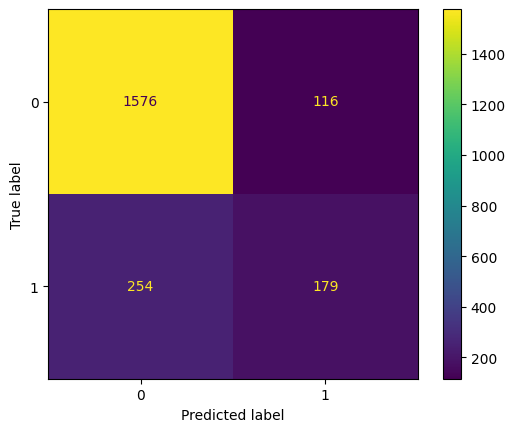

In [18]:
y_previsto = modelo.predict(x_val) # Previsões baseadas nos dados de validação

matriz_confusao = confusion_matrix(y_val, y_previsto)

visualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao)
visualizacao.plot();

In [19]:
print(classification_report(y_val, y_previsto))

              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1692
           1       0.61      0.41      0.49       433

    accuracy                           0.83      2125
   macro avg       0.73      0.67      0.69      2125
weighted avg       0.81      0.83      0.81      2125



Nesse contexto, é importante que o foco em otimizar o modelo seja em aumentar a métrica de **RECALL**, pois essa métrica tem relação direta com os **clientes de churn**. Um modelo com recall mais alto vai fazer com que o banco evite a perda de clientes.

Vou verificar os resultados com uma validação cruzada para entender melhor os resultados

## Validação Cruzada (k-fold)

Vou utilizar a validação cruzada para obter resultados mais fiéis à realidade, calculando um intervalo de confiança a partir dos resultados das amostras das validações

In [20]:
modelo = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, x, y, cv = kf, scoring = 'recall')

cv_resultados['test_score']

array([0.41741742, 0.51566952, 0.44505495, 0.45074627, 0.41260745])

In [21]:
def intervalo_conf(resultados):
    media = resultados['test_score'].mean()
    desvio_padrao = resultados['test_score'].std()
    print(f'Intervalo de confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')

In [22]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.3746357862959437, 0.5219624523661877]


Com a validação cruzada, obtemos um intervalo de confiança de 2 desvios padrões de ~ 37%-51%

In [23]:
df['Exited'].value_counts(normalize = True)

,proportion
Exited,
0,0.7962
1,0.2038


Visto o desbalanceamento dos dados, podemos realizar uma validação cruzada estratificada para obter resultados mais precisos

In [24]:
modelo = DecisionTreeClassifier(max_depth = 10)
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, x, y, cv = skf, scoring = 'recall')

In [25]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.3336194716849915, 0.5255766103392959]


O resultado ainda não melhorou na validação do k-fold estratificado. Para continuar a otimização do modelo, vou testar balancear os dados para ver se o modelo consegue melhorar seu aprendizado

# Balanceamento de dados

Nessa etapa vou utilizar a pipeline de validação para balancear os dados e o k-fold estratificado para validar o modelo.

## Oversample

Para o oversampling dos dados vou utilizar o algoritmo SMOTE

In [26]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('oversample', SMOTE()), ('arvore', modelo)])

In [27]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, x, y, cv = skf, scoring = 'recall')

intervalo_conf(cv_resultados)

Intervalo de confiança: [0.4474128623413339, 0.5641611577482866]


In [28]:
y_previsto_cv_under = cross_val_predict(pipeline, x, y, cv=kf) # Retorna as previsões da validação cruzada

print(classification_report(y, y_previsto_cv_under))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      6768
           1       0.59      0.48      0.53      1732

    accuracy                           0.83      8500
   macro avg       0.73      0.70      0.71      8500
weighted avg       0.81      0.83      0.82      8500



O oversampling dos dados melhorou o recall (50%) ✅

Vamos testar o desempenho com dados em undersample

## Undersample

Para o undersampling, vou usar o algoritmo NearMiss versão 3

In [29]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('undersample', NearMiss(version = 3)), ('arvore', modelo)])

In [30]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, x, y, cv = skf, scoring = 'recall')

intervalo_conf(cv_resultados)

Intervalo de confiança: [0.6547494505304643, 0.740186499228827]


In [31]:
y_previsto_cv_under = cross_val_predict(pipeline, x, y, cv=kf)

print(classification_report(y, y_previsto_cv_under))

              precision    recall  f1-score   support

           0       0.86      0.46      0.60      6768
           1       0.25      0.72      0.38      1732

    accuracy                           0.52      8500
   macro avg       0.56      0.59      0.49      8500
weighted avg       0.74      0.52      0.56      8500



Podemos observar no resultado do teste que o modelo apresentou uma melhora significante no recall, fazendo com que ele acerte mais previsões de clientes com churn e alcançando o objetivo de otimização do modelo.

Em contrapartida, o NearMiss **destruiu a precisão (26%)**, tornando o modelo inviável comercialmente por gerar muitos alarmes falsos.

Para tentar equilibrar a Precisão e o Recall sem precisar descartar dados com undersampling, vamos evoluir o projeto para um algoritmo de Ensemble (Random Forest) utilizando a técnica de penalização por peso de classes.

# RandomForest

In [32]:
modelo = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=5)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_resultados = cross_validate(modelo, x, y, cv=kf, scoring='recall')

intervalo_conf(cv_resultados)

Intervalo de confiança: [0.5558577085966349, 0.6531742915366295]


In [33]:
y_previsto_cv_under = cross_val_predict(modelo, x, y, cv=kf)

print(classification_report(y, y_previsto_cv_under))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      6768
           1       0.60      0.60      0.60      1732

    accuracy                           0.84      8500
   macro avg       0.75      0.75      0.75      8500
weighted avg       0.84      0.84      0.84      8500



# Teste

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      1194
           1       0.54      0.57      0.55       306

    accuracy                           0.81      1500
   macro avg       0.71      0.72      0.72      1500
weighted avg       0.82      0.81      0.82      1500



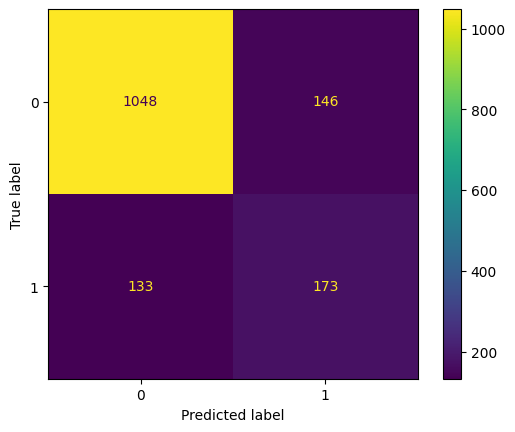

In [34]:
modelo = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=5)
modelo.fit(x, y)
y_previsto = modelo.predict(x_teste)

print(classification_report(y_teste, y_previsto))


ConfusionMatrixDisplay.from_predictions(y_teste, y_previsto);

O algoritmo do Random Forest conseguiu aumentar o desempenho da métrica-alvo (recall), do nosso modelo **sem prejudicar a precisão**, supreendentemente tendo um resultado semelhante à árvore de decisão com dados de oversampling. Dessa forma o banco consegue identificar mais clientes que desejam sair sem  confundir com tantos clientes que desejam continuar.